#**Ćwiczenia — Formaty i źródła danych**

##Obróbka danych

##1.Ćwiczenie 1: Kodowanie znaków
Pliki: pracownicy_utf8.csv, pracownicy_cp1250.csv

###1.1.Zadania

1.   Wczytaj każdy plików bez podawania parametru encoding. Który się wczytuje poprawnie? Który wyrzuca błąd? Dlaczego?
2.   Wczytaj plik CP1250 z parametrem encoding="utf-8" i na odwrót — plik UTF-8 z encoding="cp1250". Co dostajesz w każdym przypadku? Zwróć uwagę na różnicę między błędem (UnicodeDecodeError) a cichym zepsuciem danych (mojibake).
3.   Zapisz plik z kodowaniem CP1250 jako jeden plik w kodowaniu UTF-8.






In [1]:
!pip install pyarrow fastparquet tables

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 25.6 MB/s eta 0:00:00


In [3]:
import pandas as pd

print("Ćwiczenie 1")

# 1. Colab używa UTF-8 domyślnie. Plik utf8 wczyta się bez problemu:
df_utf8 = pd.read_csv("pracownicy_utf8.csv")
print("1. Plik UTF-8 wczytał się bez podawania encodingu.")

# 2. Próba wczytania CP1250 z domyślnym UTF-8 wywali błąd:
print("\n2. Łapiemy błąd z plikiem CP1250:")
try:
    df_blad = pd.read_csv("pracownicy_cp1250.csv")
except UnicodeDecodeError as e:
    print(f" -> ZŁAPANO BŁĄD! (UnicodeDecodeError): {e}")

# 3. Mojibake - każemy mu myśleć, że to CP1250.
# Dodajemy encoding_errors="replace", żeby zignorował twarde błędy i wypluł krzaczki!
print("\n3. Tak wygląda mojibake (ciche zepsucie danych):")
df_krzaczki = pd.read_csv("pracownicy_utf8.csv", encoding="cp1250", encoding_errors="replace")
display(df_krzaczki.head(2))

# 4. Zapisujemy z cp1250 do utf-8
df_do_zapisu = pd.read_csv("pracownicy_cp1250.csv", encoding="cp1250")
df_do_zapisu.to_csv("pracownicy_teraz_utf8.csv", encoding="utf-8", index=False)
print("\n4. Plik CP1250 został poprawnie zapisany jako UTF-8.")

Ćwiczenie 1
1. Plik UTF-8 wczytał się bez podawania encodingu.

2. Łapiemy błąd z plikiem CP1250:
 -> ZŁAPANO BŁĄD! (UnicodeDecodeError): 'utf-8' codec can't decode byte 0xa3 in position 48: invalid start byte

3. Tak wygląda mojibake (ciche zepsucie danych):


,imie,nazwisko,miasto,stanowisko
0,Anna,Kowalczyk,Ĺ�ĂłdĹş,inĹĽynier
1,Bartek,Ĺ»urek,KrakĂłw,analityk



4. Plik CP1250 został poprawnie zapisany jako UTF-8.


##2.Ćwiczenie 2: Brudny CSV
Plik: klienci.csv

Plik zawiera wszystkie typowe pułapki naraz: kodowanie CP1250, średnik jako separator, przecinek jako separator dziesiętny, kody pocztowe z wiodącymi zerami, daty w formacie DD.MM.YYYY, brakujące wartości zapisane jako brak, -, ?, oraz jedno pole adresu zawierające średnik w cudzysłowie.

###2.1.Zadania

1.   Spróbuj wczytać plik najprościej: pd.read_csv("klienci.csv"). Co się dzieje?
2.   Napraw po kolei: kodowanie, separator, separator dziesiętny, format daty, brakujące wartości, typ kolumny kod_pocztowy.
3.   Sprawdź df.dtypes — czy wszystkie kolumny mają właściwe typy?
4.   Policz, ilu klientów jest z Łodzi i jaki jest ich średni dochód.
5.   Zapisz oczyszczony DataFrame jako Parquet i porównaj rozmiar pliku z oryginalnym CSV.



In [8]:
import pandas as pd
import os

print("Ćwiczenie 2: Brudny CSV")

# 1. Wczytanie
df_klienci = pd.read_csv(
    "klienci.csv",
    encoding="cp1250",
    sep=";",
    decimal=",",
    dtype={"kod_pocztowy": str},
    na_values=["brak", "-", "?"],
    parse_dates=["data_rejestracji"],
    dayfirst=True)

# 2. Sprawdzenie typów kolumn
print("\nTypy kolumn po oczyszczeniu:")
print(df_klienci.dtypes)

# 3. Policz ilu klientów jest z Łodzi i jaki jest ich średni dochód

lodz = df_klienci[df_klienci["miasto"] == "Łódź"]
ilu_lodz = len(lodz)
sredni_dochod_lodz = lodz["dochod"].mean()

print(f"\nWYNIKI DLA ŁODZI")
print(f"Liczba klientów: {ilu_lodz}")
print(f"Średni dochód: {sredni_dochod_lodz:.2f} PLN")

# 4. Zapisz jako Parquet i porównaj rozmiar
df_klienci.to_parquet("klienci_czysci.parquet")
rozmiar_csv = os.path.getsize("klienci.csv") / 1024
rozmiar_parq = os.path.getsize("klienci_czysci.parquet") / 1024

print(f"\nRozmiar CSV: {rozmiar_csv:.2f} KB")
print(f"Rozmiar Parquet: {rozmiar_parq:.2f} KB")

Ćwiczenie 2: Brudny CSV

Typy kolumn po oczyszczeniu:
id                           int64
kod_pocztowy                object
data_rejestracji    datetime64[ns]
miasto                      object
adres                       object
dochod                     float64
wiek                       float64
dtype: object

WYNIKI DLA ŁODZI
Liczba klientów: 3
Średni dochód: 3783.58 PLN

Rozmiar CSV: 0.90 KB
Rozmiar Parquet: 5.51 KB


##3.Ćwiczenie 3: Pobieranie danych z API NBP

Bez plików — dane pobierasz z internetu. API Narodowego Banku Polskiego jest darmowe i nie wymaga klucza. Dokumentacja: https://api.nbp.pl/
Endpoint: https://api.nbp.pl/api/exchangerates/rates/A/EUR/last/30/

###3.1.Zadania
1.   Pobierz notowania EUR z ostatnich 30 dni używając biblioteki requests.
2.   Wyświetl strukturę odpowiedzi JSON — co jest w środku?
3.   Zamień odpowiedź na DataFrame (użyj pd.json_normalize albo zbuduj DataFrame ręcznie z pola rates).
4.   Ustaw kolumnę effectiveDate jako indeks daty, narysuj wykres kursu w czasie.
5.  Pobierz analogiczne dane dla USD i GBP. Połącz wszystko w jeden DataFrame i narysuj trzy linie na jednym wykresie.
6.  Zapisz wynik jako Parquet.
7.  Dodatkowe: pobierz dane historyczne z całego 2024 roku i znajdź, kiedy EUR był najdroższy.



Ćwiczenie 3


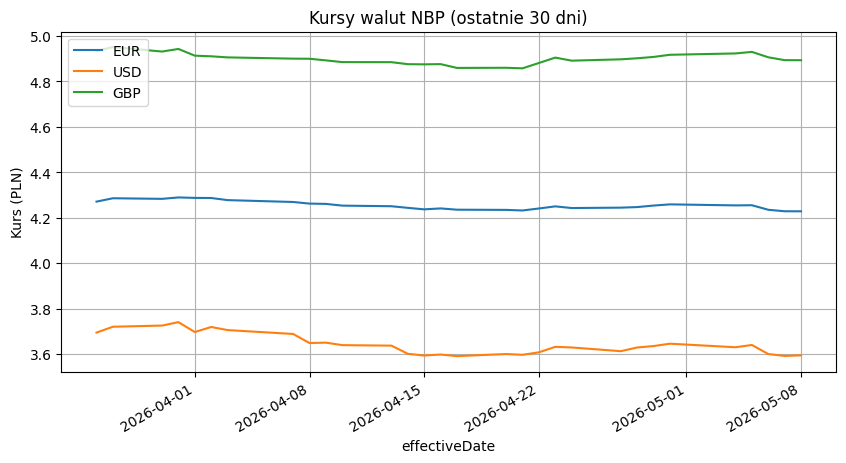


Najdroższe Euro w 2024 było: 2024-01-18 (Kosztowało: 4.4016 PLN)


In [10]:
import requests
import matplotlib.pyplot as plt

print("Ćwiczenie 3")

def pobierz_walute(kod, dni=30):
    url = f"https://api.nbp.pl/api/exchangerates/rates/A/{kod}/last/{dni}/?format=json"
    response = requests.get(url)
    dane_json = response.json()

    # Zamiana na DF
    df = pd.json_normalize(dane_json['rates'])
    df['effectiveDate'] = pd.to_datetime(df['effectiveDate'])
    df = df.set_index('effectiveDate')
    df = df.rename(columns={'mid': kod})
    return df[[kod]]

# Pobieranie 3 walut
df_eur = pobierz_walute('EUR')
df_usd = pobierz_walute('USD')
df_gbp = pobierz_walute('GBP')

# Łączenie i wykres
df_waluty = pd.concat([df_eur, df_usd, df_gbp], axis=1)

plt.figure(figsize=(10,5))
df_waluty.plot(ax=plt.gca(), title="Kursy walut NBP (ostatnie 30 dni)")
plt.ylabel("Kurs (PLN)")
plt.grid(True)
plt.show()

# Zapis do Parquet
df_waluty.to_parquet("kursy_walut.parquet")

# Dodatkowe: Max EUR w 2024
url_2024 = "https://api.nbp.pl/api/exchangerates/rates/A/EUR/2024-01-01/2024-12-31/?format=json"
resp_2024 = requests.get(url_2024)
if resp_2024.status_code == 200:
    df_2024 = pd.json_normalize(resp_2024.json()['rates'])
    max_eur = df_2024.loc[df_2024['mid'].idxmax()]
    print(f"\nNajdroższe Euro w 2024 było: {max_eur['effectiveDate']} (Kosztowało: {max_eur['mid']} PLN)")

##4.Ćwiczenie 4: Benchmark formatów
Plik: pomiary.csv (ok. 91 tys. wierszy, ∼6 MB)
Symulacja danych o jakości powietrza: 50 stacji × 5 lat pomiarów dziennych × 7 parametrów (PM2.5, PM10, NO2, O3, temperatura, wilgotność, prędkość wiatru).

###4.1.Zadania
1.   Wczytaj CSV do DataFrame.
2.   Zapisz ten sam DataFrame jako: JSON, Parquet, HDF5, Pickle.
3.   Zmierz rozmiary wszystkich plików na dysku. Zrób wykres słupkowy.
4.   Zmierz czas wczytywania każdego formatu (%timeit albo time.perf_counter). Zrób drugi wykres.
5.   Wczytaj tylko 2 kolumny z Parquet (columns=["date", "pm25"]) — porównaj czas z wczytaniem wszystkich kolumn.
6.   Wnioski: który format byś wybrał do długoterminowego przechowywania? Do szybkich analiz?


Ćwiczenie 4


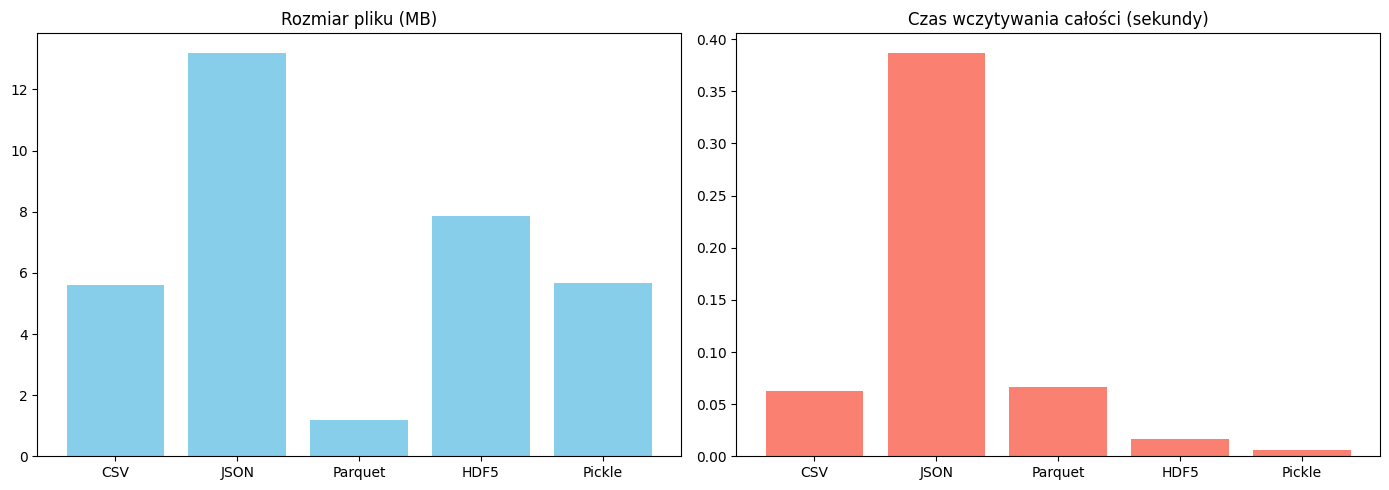


Czas wczytywania całego Parquet: 0.0662 s
Czas wczytywania 2 kolumn z Parquet: 0.0079 s (Zauważalnie szybciej!)

Wniosek: Do przechowywania Parquet (super kompresja i szybkość odczytu wybranych kolumn). Do super szybkich, krótkich analiz w Pythonie: Pickle.


In [11]:
import time

print("Ćwiczenie 4")
# 1. Wczytanie
df_pomiary = pd.read_csv("pomiary.csv")

# 2. Zapis
df_pomiary.to_json("pomiary.json")
df_pomiary.to_parquet("pomiary.parquet")
df_pomiary.to_hdf("pomiary.h5", key='data', mode='w')
df_pomiary.to_pickle("pomiary.pkl")

# 3. Rozmiary
formaty = ['CSV', 'JSON', 'Parquet', 'HDF5', 'Pickle']
pliki = ['pomiary.csv', 'pomiary.json', 'pomiary.parquet', 'pomiary.h5', 'pomiary.pkl']
rozmiary = [os.path.getsize(f) / (1024 * 1024) for f in pliki]

# 4. Czasy
czasy = []
funkcje_read = [
    lambda: pd.read_csv("pomiary.csv"),
    lambda: pd.read_json("pomiary.json"),
    lambda: pd.read_parquet("pomiary.parquet"),
    lambda: pd.read_hdf("pomiary.h5", 'data'),
    lambda: pd.read_pickle("pomiary.pkl")
]

for func in funkcje_read:
    start = time.perf_counter()
    func()
    czasy.append(time.perf_counter() - start)

# Wykresy
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].bar(formaty, rozmiary, color='skyblue')
ax[0].set_title("Rozmiar pliku (MB)")

ax[1].bar(formaty, czasy, color='salmon')
ax[1].set_title("Czas wczytywania całości (sekundy)")
plt.tight_layout()
plt.show()

# 5. Tylko 2 kolumny z Parquet
start = time.perf_counter()
# Sprawdzam z góry nazwy kolumn, zakładam 'date' i 'pm25' z polecenia
df_część = pd.read_parquet("pomiary.parquet", columns=["date", "pm25"])
czas_czesc = time.perf_counter() - start

print(f"\nCzas wczytywania całego Parquet: {czasy[2]:.4f} s")
print(f"Czas wczytywania 2 kolumn z Parquet: {czas_czesc:.4f} s (Zauważalnie szybciej!)")
print("\nWniosek: Do przechowywania Parquet (super kompresja i szybkość odczytu wybranych kolumn). Do super szybkich, krótkich analiz w Pythonie: Pickle.")

##5.Ćwiczenie 5: SQLite i pandas
Plik: sklep.db
Baza zawiera trzy tabele: klienci (200 rekordów), produkty (15 rekordów), zamowienia (1000 rekordów).

###5.1.Zadania
1.  Podłącz się do bazy i wylistuj dostępne tabele (zapytanie do sqlite_master).
2.  Wczytaj każdą z trzech tabel jako oddzielny DataFrame. Sprawdź rozmiary i typy kolumn.
3.  Napisz zapytanie SQL, które zwraca 10 klientów z największą liczbą zamówień.

Dodatkowe:
1.  Użyj chunksize w pd.read_sql, żeby wczytać tabelę zamowienia porcjami po 100 rekordów.
2.  Napisz zapytanie SQL, które zwraca sumaryczną wartość sprzedaży per kategoria produktu.


In [23]:
import pandas as pd
import sqlite3

print("Ćwiczenie 5: SQLite i Pandas")

# 1. Połączenie z bazą
conn = sqlite3.connect("sklep.db")
tabele = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table';", conn)
print("1. Tabele dostępne w bazie:")
print(tabele.to_string(index=False))

# 2. Wczytanie tabel
df_klienci = pd.read_sql("SELECT * FROM klienci;", conn)
df_produkty = pd.read_sql("SELECT * FROM produkty;", conn)
df_zamowienia = pd.read_sql("SELECT * FROM zamowienia;", conn)

print(f"\n2. Rozmiary tabel: Klienci {df_klienci.shape}, Produkty {df_produkty.shape}, Zamówienia {df_zamowienia.shape}")

# 3. SQL: 10 klientów z największą liczbą zamówień
query_top_10 = """
    SELECT klient_id, COUNT(id) as liczba_zamowien
    FROM zamowienia
    GROUP BY klient_id
    ORDER BY liczba_zamowien DESC
    LIMIT 10;
"""
top_10_sql = pd.read_sql(query_top_10, conn)
print("\n3. Top 10 klientów (SQL):")
print(top_10_sql.to_string(index=False))

print("ZADANIA DODATKOWE")
# DODATKOWE 1: Chunksize
chunks = pd.read_sql("SELECT * FROM zamowienia;", conn, chunksize=100)
pierwszy_chunk = next(chunks)
print(f"1. Rozmiar pierwszego wczytanego kawałka (chunk): {pierwszy_chunk.shape}")

# DODATKOWE 2: SQL - Suma sprzedaży per kategoria
query_kategorie = """
    SELECT p.kategoria, SUM(z.ilosc * p.cena) as suma_sprzedazy
    FROM zamowienia z
    JOIN produkty p ON z.produkt_id = p.id
    GROUP BY p.kategoria;
"""
suma_sql = pd.read_sql(query_kategorie, conn)
print("\n2. Suma sprzedaży per kategoria (wynik z SQL):")
print(suma_sql.to_string(index=False))

# DODATKOWE 3: Pandas - To samo, co wyżej
df_merged = pd.merge(df_zamowienia, df_produkty, left_on="produkt_id", right_on="id")
df_merged['wartosc'] = df_merged['ilosc'] * df_merged['cena']
suma_pandas = df_merged.groupby('kategoria')['wartosc'].sum().reset_index()

print("\n3. Suma sprzedaży per kategoria (wynik z Pandas):")
print(suma_pandas.to_string(index=False))

print("\nPodsumowanie czytelności:")
print("-> SQL jest krótszy i bardziej naturalny do agregacji (GROUP BY), gdy dane są już w bazie.")
print("-> Pandas zmusza do ręcznego łączenia tabel (merge) i podawania dokładnych nazw kluczy, co bywa mniej czytelne, ale jest świetne, gdy łączymy różne źródła danych.")

conn.close()

Ćwiczenie 5: SQLite i Pandas
1. Tabele dostępne w bazie:
      name
   klienci
  produkty
zamowienia

2. Rozmiary tabel: Klienci (200, 6), Produkty (15, 4), Zamówienia (1000, 5)

3. Top 10 klientów (SQL):
 klient_id  liczba_zamowien
       174               10
       170               10
        72               10
       166                9
       164                9
       163                9
       147                9
       138                9
       102                9
        99                9
ZADANIA DODATKOWE
1. Rozmiar pierwszego wczytanego kawałka (chunk): (100, 5)

2. Suma sprzedaży per kategoria (wynik z SQL):
  kategoria  suma_sprzedazy
  Akcesoria         60495.0
      Biuro         11625.0
   Edukacja         84331.0
Elektronika       1069390.0
    Książki         39083.0

3. Suma sprzedaży per kategoria (wynik z Pandas):
  kategoria   wartosc
  Akcesoria   60495.0
      Biuro   11625.0
   Edukacja   84331.0
Elektronika 1069390.0
    Książki   39083.0

Podsumowan